# Tính KPI / Chỉ số kỹ thuật cho VN30

**Đồ án:** Thu thập, xử lý và đánh giá tương quan thay đổi giá chứng khoán với tin tức
**Nội dung 1 — Tính KPI giá.**

Notebook này đọc dữ liệu giá OHLCV đã thu thập (`supabase_ready/stock_prices.csv`),
tính 15 chỉ số kỹ thuật cho 30 mã **VN30** giai đoạn **2022 → nay**, kiểm tra chất
lượng và trực quan hoá. Kết quả lưu ra `technical_indicators.csv`.

| Nhóm | KPI |
|---|---|
| Sinh lời | `daily_return`, `log_return` |
| Xu hướng | `ma_20`, `ma_50`, `macd`, `macd_signal`, `macd_hist` |
| Biến động | `volatility_20`, `bb_upper`, `bb_lower`, `bb_pctb` |
| Động lượng | `rsi_14`, `volume_change`, `obv` |
| Rủi ro | `drawdown` |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (13, 4)


## 1. Cấu hình

`PRICES_CSV` trỏ tới file giá đã thu thập. `VN30` là rổ 30 mã (đồng bộ với bộ lọc
tin tức VN30) — dùng để lọc đúng phạm vi đồ án.


In [2]:
from pathlib import Path

PRICES_CSV = Path("supabase_ready") / "stock_prices.csv"
START_DATE = "2022-01-01"          # giai đoạn quan tâm
OUT_CSV    = "technical_indicators.csv"

VN30 = [
    "ACB", "BCM", "BID", "BVH", "CTG", "FPT", "GAS", "GVR", "HDB", "HPG",
    "LPB", "MBB", "MSN", "MWG", "PLX", "SAB", "SHB", "SSB", "SSI", "STB",
    "TCB", "TPB", "VCB", "VHM", "VIB", "VIC", "VJC", "VNM", "VPB", "VRE",
]
len(VN30)


30

## 2. Đọc & làm sạch dữ liệu giá

File giá gồm toàn bộ HOSE (~4.6M dòng) nên đọc theo chunk + lọc VN30 ngay để tiết
kiệm bộ nhớ. Sau đó loại các dòng lỗi (`close <= 0` hoặc ngày không hợp lệ).


In [3]:
cols = ["symbol", "date", "open", "high", "low", "close", "volume"]
chunks = []
for ch in pd.read_csv(PRICES_CSV, usecols=cols, chunksize=500_000):
    chunks.append(ch[ch["symbol"].isin(VN30)])
df = pd.concat(chunks, ignore_index=True)

df["date"]  = pd.to_datetime(df["date"], errors="coerce")
df["close"] = pd.to_numeric(df["close"], errors="coerce")
df = df[(df["date"].notna()) & (df["close"] > 0)].copy()
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

print(f"Số dòng VN30 (toàn lịch sử): {len(df):,} | số mã: {df['symbol'].nunique()}")
print(f"Khoảng ngày: {df['date'].min().date()} → {df['date'].max().date()}")
df.head()


Số dòng VN30 (toàn lịch sử): 93,758 | số mã: 30
Khoảng ngày: 2009-03-31 → 2026-04-03


,symbol,date,open,high,low,close,volume
0,ACB,2009-03-31,2.77,2.84,2.73,2.84,1627000
1,ACB,2009-04-01,2.92,2.94,2.81,2.92,1854800
2,ACB,2009-04-02,2.97,3.01,2.93,2.97,2515500
3,ACB,2009-04-03,3.06,3.17,2.98,3.17,5193700
4,ACB,2009-04-07,3.31,3.34,3.16,3.34,3772200


## 3. Hàm tính KPI

Mỗi KPI tính trên **từng mã** (chuỗi đã sort theo ngày):

- **daily_return / log_return**: tỷ suất sinh lời ngày.
- **ma_20, ma_50**: trung bình động 20/50 phiên — xu hướng ngắn/trung hạn.
- **volatility_20**: độ lệch chuẩn log-return cuộn 20 ngày — mức biến động.
- **rsi_14**: chỉ báo quá mua (>70) / quá bán (<30), dùng làm trơn Wilder.
- **macd**: `EMA12 − EMA26`; `macd_signal = EMA9(macd)`; `macd_hist` = hiệu.
- **Bollinger**: `MA20 ± 2σ`; `bb_pctb` = vị trí giá trong dải [0,1].
- **volume_change / obv**: động lượng khối lượng (OBV = On-Balance Volume).
- **drawdown**: mức sụt so với đỉnh tích luỹ.


In [4]:
def compute_kpis(g: pd.DataFrame) -> pd.DataFrame:
    # Tính KPI cho 1 mã (g đã sort theo date tăng dần).
    out = g.copy()
    c = out["close"].astype(float)
    v = out["volume"].astype(float)

    # Sinh lời
    out["daily_return"] = c.pct_change()
    out["log_return"]   = np.log(c / c.shift(1))

    # Xu hướng
    out["ma_20"] = c.rolling(20).mean()
    out["ma_50"] = c.rolling(50).mean()

    # Biến động
    out["volatility_20"] = out["log_return"].rolling(20).std()

    # RSI(14) — Wilder smoothing
    delta = c.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    rs = avg_gain / avg_loss
    out["rsi_14"] = 100 - 100 / (1 + rs)

    # MACD (12,26,9)
    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    out["macd"]        = ema12 - ema26
    out["macd_signal"] = out["macd"].ewm(span=9, adjust=False).mean()
    out["macd_hist"]   = out["macd"] - out["macd_signal"]

    # Bollinger Bands (20, 2σ)
    std20 = c.rolling(20).std()
    out["bb_upper"] = out["ma_20"] + 2 * std20
    out["bb_lower"] = out["ma_20"] - 2 * std20
    width = (out["bb_upper"] - out["bb_lower"]).replace(0, np.nan)
    out["bb_pctb"]  = (c - out["bb_lower"]) / width

    # Khối lượng
    out["volume_change"] = v.pct_change()
    out["obv"] = (np.sign(c.diff()).fillna(0) * v).cumsum()

    # Drawdown
    running_max = c.cummax()
    out["drawdown"] = (c - running_max) / running_max
    return out


## 4. Tính KPI cho VN30 rồi cắt từ 2022

**Quan trọng:** tính trên *toàn bộ lịch sử* rồi mới cắt từ `START_DATE`, để các cửa
sổ trượt (MA50, RSI...) đã "đủ ấm" — không bị thiếu giá trị đầu kỳ.


In [5]:
parts = [compute_kpis(g) for _, g in df.groupby("symbol", sort=False)]
kpi = pd.concat(parts, ignore_index=True)

kpi = kpi[kpi["date"] >= pd.Timestamp(START_DATE)].copy().reset_index(drop=True)
kpi.to_csv(OUT_CSV, index=False, encoding="utf-8")

print(f"Đã ghi {len(kpi):,} dòng → {OUT_CSV}")
kpi.tail(3)


Đã ghi 31,710 dòng → technical_indicators.csv


,symbol,date,open,high,low,close,volume,daily_return,log_return,ma_20,ma_50,volatility_20,rsi_14,macd,macd_signal,macd_hist,bb_upper,bb_lower,bb_pctb,volume_change,obv,drawdown
31707,VRE,2026-04-01,26.8,27.55,26.7,27.55,10207100,0.069903,0.067568,25.8200,28.132,0.033730,54.673710,-0.550428,-0.833432,0.283005,27.375093,24.264907,1.056237,3.078435,615034654.0,-0.430432
31708,VRE,2026-04-02,28.0,28.30,27.2,27.20,6533700,-0.012704,-0.012786,25.8300,28.047,0.032822,52.570979,-0.424064,-0.751559,0.327495,27.419240,24.240760,0.931024,-0.359887,608500954.0,-0.437668
31709,VRE,2026-04-03,27.0,28.25,27.0,27.20,2697700,0.000000,0.000000,25.8775,27.951,0.032130,52.570979,-0.320228,-0.665293,0.345064,27.572842,24.182158,0.890039,-0.587110,608500954.0,-0.437668


## 5. Kiểm tra chất lượng

- RSI phải nằm trong [0, 100].
- daily_return nên trong khoảng ±7% (biên độ sàn HOSE).
- Số NaN ở mỗi KPI nên = 0 (vì đã tính trên toàn lịch sử trước khi cắt).


In [6]:
print("RSI range      :", round(kpi['rsi_14'].min(), 1), "→", round(kpi['rsi_14'].max(), 1))
print("daily_return   :", round(kpi['daily_return'].min(), 3), "→", round(kpi['daily_return'].max(), 3))
print("Số mã          :", kpi['symbol'].nunique())
print("Khoảng ngày    :", kpi['date'].min().date(), "→", kpi['date'].max().date())
print("Số ngày / mã   :", int(kpi.groupby('symbol').size().mean()))
print("\nNaN mỗi KPI:")
kpi_cols = [c for c in kpi.columns if c not in cols]
print(kpi[kpi_cols].isna().sum())


RSI range      : 6.6 → 95.4
daily_return   : -0.071 → 0.072
Số mã          : 30
Khoảng ngày    : 2022-01-04 → 2026-04-03
Số ngày / mã   : 1057

NaN mỗi KPI:
daily_return     0
log_return       0
ma_20            0
ma_50            0
volatility_20    0
rsi_14           0
macd             0
macd_signal      0
macd_hist        0
bb_upper         0
bb_lower         0
bb_pctb          0
volume_change    0
obv              0
drawdown         0
dtype: int64


## 6. Trực quan hoá — giá + MA + Bollinger + RSI (1 mã)

Đổi `SYM` để xem mã khác.


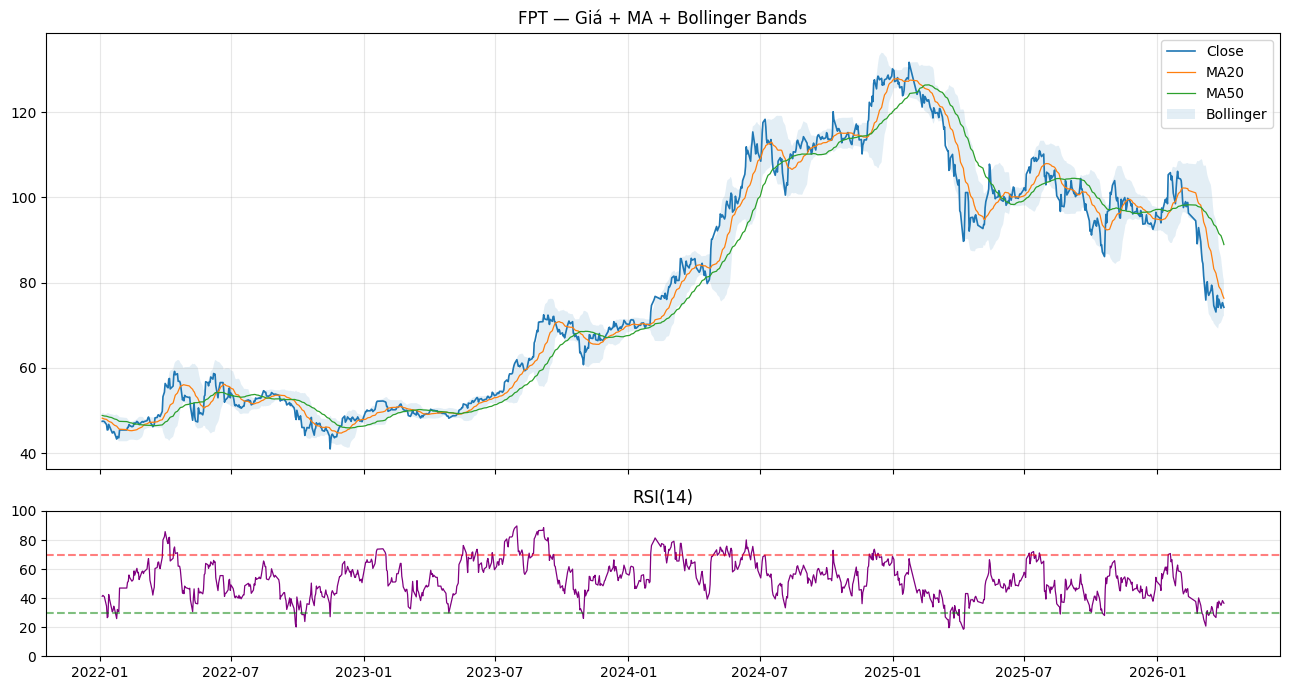

In [7]:
SYM = "FPT"
s = kpi[kpi["symbol"] == SYM]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(s["date"], s["close"], label="Close", lw=1.2)
ax1.plot(s["date"], s["ma_20"], label="MA20", lw=0.9)
ax1.plot(s["date"], s["ma_50"], label="MA50", lw=0.9)
ax1.fill_between(s["date"], s["bb_lower"], s["bb_upper"], alpha=0.12, label="Bollinger")
ax1.set_title(f"{SYM} — Giá + MA + Bollinger Bands"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(s["date"], s["rsi_14"], color="purple", lw=0.9)
ax2.axhline(70, color="red", ls="--", alpha=0.5); ax2.axhline(30, color="green", ls="--", alpha=0.5)
ax2.set_ylim(0, 100); ax2.set_title("RSI(14)"); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 7. Phân phối daily return toàn VN30

Kiểm tra phân phối tỷ suất sinh lời (thường nhọn, đuôi dày) + so sánh độ biến động giữa các mã.


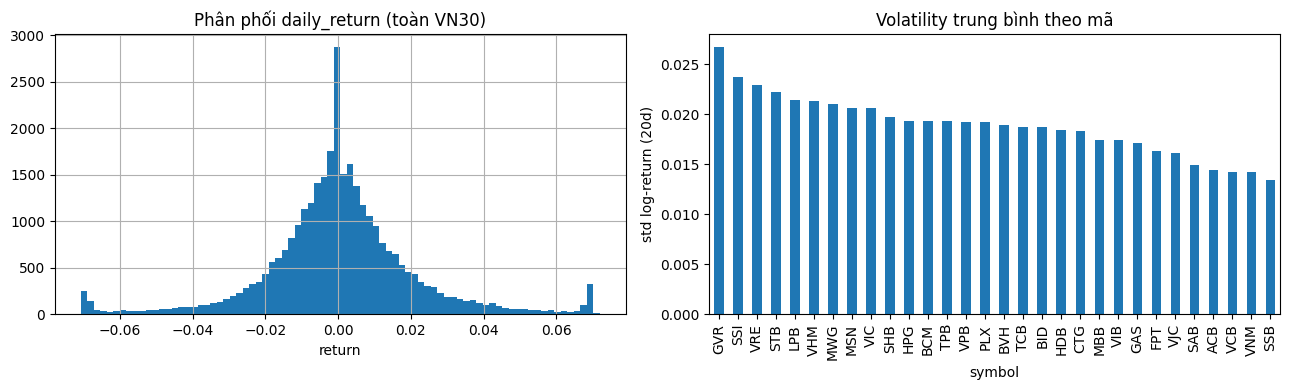

: 

In [ ]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4))
kpi["daily_return"].hist(bins=80, ax=axA)
axA.set_title("Phân phối daily_return (toàn VN30)"); axA.set_xlabel("return")

vol = kpi.groupby("symbol")["volatility_20"].mean().sort_values(ascending=False)
vol.plot.bar(ax=axB)
axB.set_title("Volatility trung bình theo mã"); axB.set_ylabel("std log-return (20d)")
plt.tight_layout(); plt.show()
